# 第三阶段 B：MPC 教师数据生成与质量审计

## 研究问题

能否从**动力学上可达的充电轨迹**中采样状态，用约束 MPC 生成可审计的最优电流标签，并建立一个没有轨迹泄漏、覆盖约束边界的数据集，为下一阶段 DNN 显式控制器训练做准备？

本阶段**不训练 DNN**。通过只表示数据具备开始第一版训练实验的最低条件，不表示 DNN 已安全、MPC 已优于所有基线，或该方法可直接用于实物电池。

## 教师映射与第一版 DNN 输入

监督学习目标是逼近 MPC 的第一步控制动作：

\[
\pi_\theta(x_k^{DNN})\approx I_k^\star,
\qquad
x_k^{DNN}=[z_k,v_{1,k},v_{2,k},T_{avg,k},I_{k-1}]^{\mathsf T}.
\]

其中 \(z\) 为 SOC，\(v_1,v_2\) 为 2RC 极化压降，\(T_{avg}\) 为平均温度，\(I_{k-1}\) 为上一控制电流。核心/表面热节点只用于教师模型内部审计，因为 Chen2020 缺少空间温度验证条件，不能把它们当作已验证的可测 DNN 输入。

## 为什么只从可达轨迹采样？

极化电压、温度和上一时刻电流均带有历史记忆。独立随机拼接这些变量可能产生任何真实电流历史都无法到达的状态。因此，从统一初态

\[
x_0=[0.1,0,0,25,25,0]^{\mathsf T}
\]

出发，施加 12 种受约束探索策略，再按 SOC 分箱抽样。训练、验证和测试按**整条轨迹**划分，避免相邻时刻同时出现在不同集合中造成数据泄漏。

In [1]:
from pathlib import Path
import json
import os
import pandas as pd
from IPython.display import Image, display

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase3b.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase3b_config import load_phase_three_b_config
from battery_fast_charge.phase3b_runner import run_phase_three_b
from battery_fast_charge.phase3_config import load_phase_three_config

config = load_phase_three_b_config(PROJECT_ROOT / "configs" / "phase3b.yaml")
phase3_config = load_phase_three_config(PROJECT_ROOT / config.source_phase3_config)
print(f"研究：{config.study_name}")
print(f"探索轨迹数：{len(config.dataset.rollouts)}")
print(f"SOC范围：{phase3_config.battery.initial_soc:.0%} → "
      f"{phase3_config.battery.target_soc:.0%}")

研究：chen2020_phase3b_mpc_teacher_dataset
探索轨迹数：12
SOC范围：10% → 80%


## 运行或读取正式结果

默认读取仓库中的正式结果，几秒内即可复核本 notebook。若将 `RUN_PHASE3B` 改为 `True`，会重新生成全部轨迹和标签，并运行 Chen2020 DFN 公平基线，通常需要数分钟。

In [2]:
RUN_PHASE3B = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase3b_metrics.json"
comparison_path = PROJECT_ROOT / "outputs" / "metrics" / "phase3b_same_constraint_comparison.csv"
dataset_path = PROJECT_ROOT / "data" / "phase3b" / "teacher_dataset.csv"
attempts_path = PROJECT_ROOT / "data" / "phase3b" / "teacher_label_attempts.csv"
rollouts_path = PROJECT_ROOT / "data" / "phase3b" / "reachable_rollouts.csv"

required = [metrics_path, comparison_path, dataset_path, attempts_path, rollouts_path]
if RUN_PHASE3B or any(not path.exists() for path in required):
    run_phase_three_b(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
comparison = pd.read_csv(comparison_path)
dataset = pd.read_csv(dataset_path)
attempts = pd.read_csv(attempts_path)
rollouts = pd.read_csv(rollouts_path)

## 数据集质量闸门

In [3]:
quality = metrics["dataset_quality"]
quality_summary = pd.Series({
    "候选状态数": quality["candidate_count"],
    "接受标签数": quality["accepted_count"],
    "拒绝标签数": quality["rejected_count"],
    "教师接受率 [%]": 100 * quality["teacher_acceptance_fraction"],
    "重复特征行": quality["duplicate_feature_row_count"],
    "平均 MPC 求解时间 [ms]": quality["mean_teacher_solve_time_ms"],
    "最大 MPC 求解时间 [ms]": quality["maximum_teacher_solve_time_ms"],
    "数据质量通过": quality["success"],
})
display(quality_summary.to_frame("结果").round(3))

checks = pd.Series(quality["checks"], name="通过")
display(checks.to_frame())

,结果
候选状态数,168
接受标签数,168
拒绝标签数,0
教师接受率 [%],100.0
重复特征行,0
平均 MPC 求解时间 [ms],496.469836
最大 MPC 求解时间 [ms],2075.8276
数据质量通过,True


,通过
candidate_count,True
teacher_acceptance_fraction,True
minimum_samples_per_split,True
minimum_samples_per_soc_bin,True
trajectory_split_isolation,True
reachable_sources_only,True
label_current_bounds,True
voltage_active_coverage,True
temperature_active_coverage,True


## 轨迹隔离、SOC 覆盖与活跃约束

In [4]:
audit = pd.DataFrame({
    "样本数": quality["split_counts"],
    "整轨迹数": quality["trajectory_split_counts"],
}).fillna(0).astype(int)
display(audit)

soc_coverage = pd.Series(quality["soc_bin_counts"], name="样本数")
soc_coverage.index.name = "SOC分箱编号（0代表10%–20%）"
display(soc_coverage.to_frame())

active = pd.Series(quality["active_constraint_counts"], name="活跃样本数")
display(active.to_frame())

,样本数,整轨迹数
train,112,8
test,28,2
validation,28,2


,样本数
SOC分箱编号（0代表10%–20%）,
0,24
1,24
2,24
3,24
4,24
5,24
6,24


,活跃样本数
voltage,48
temperature,144
current_upper,0
current_change,16


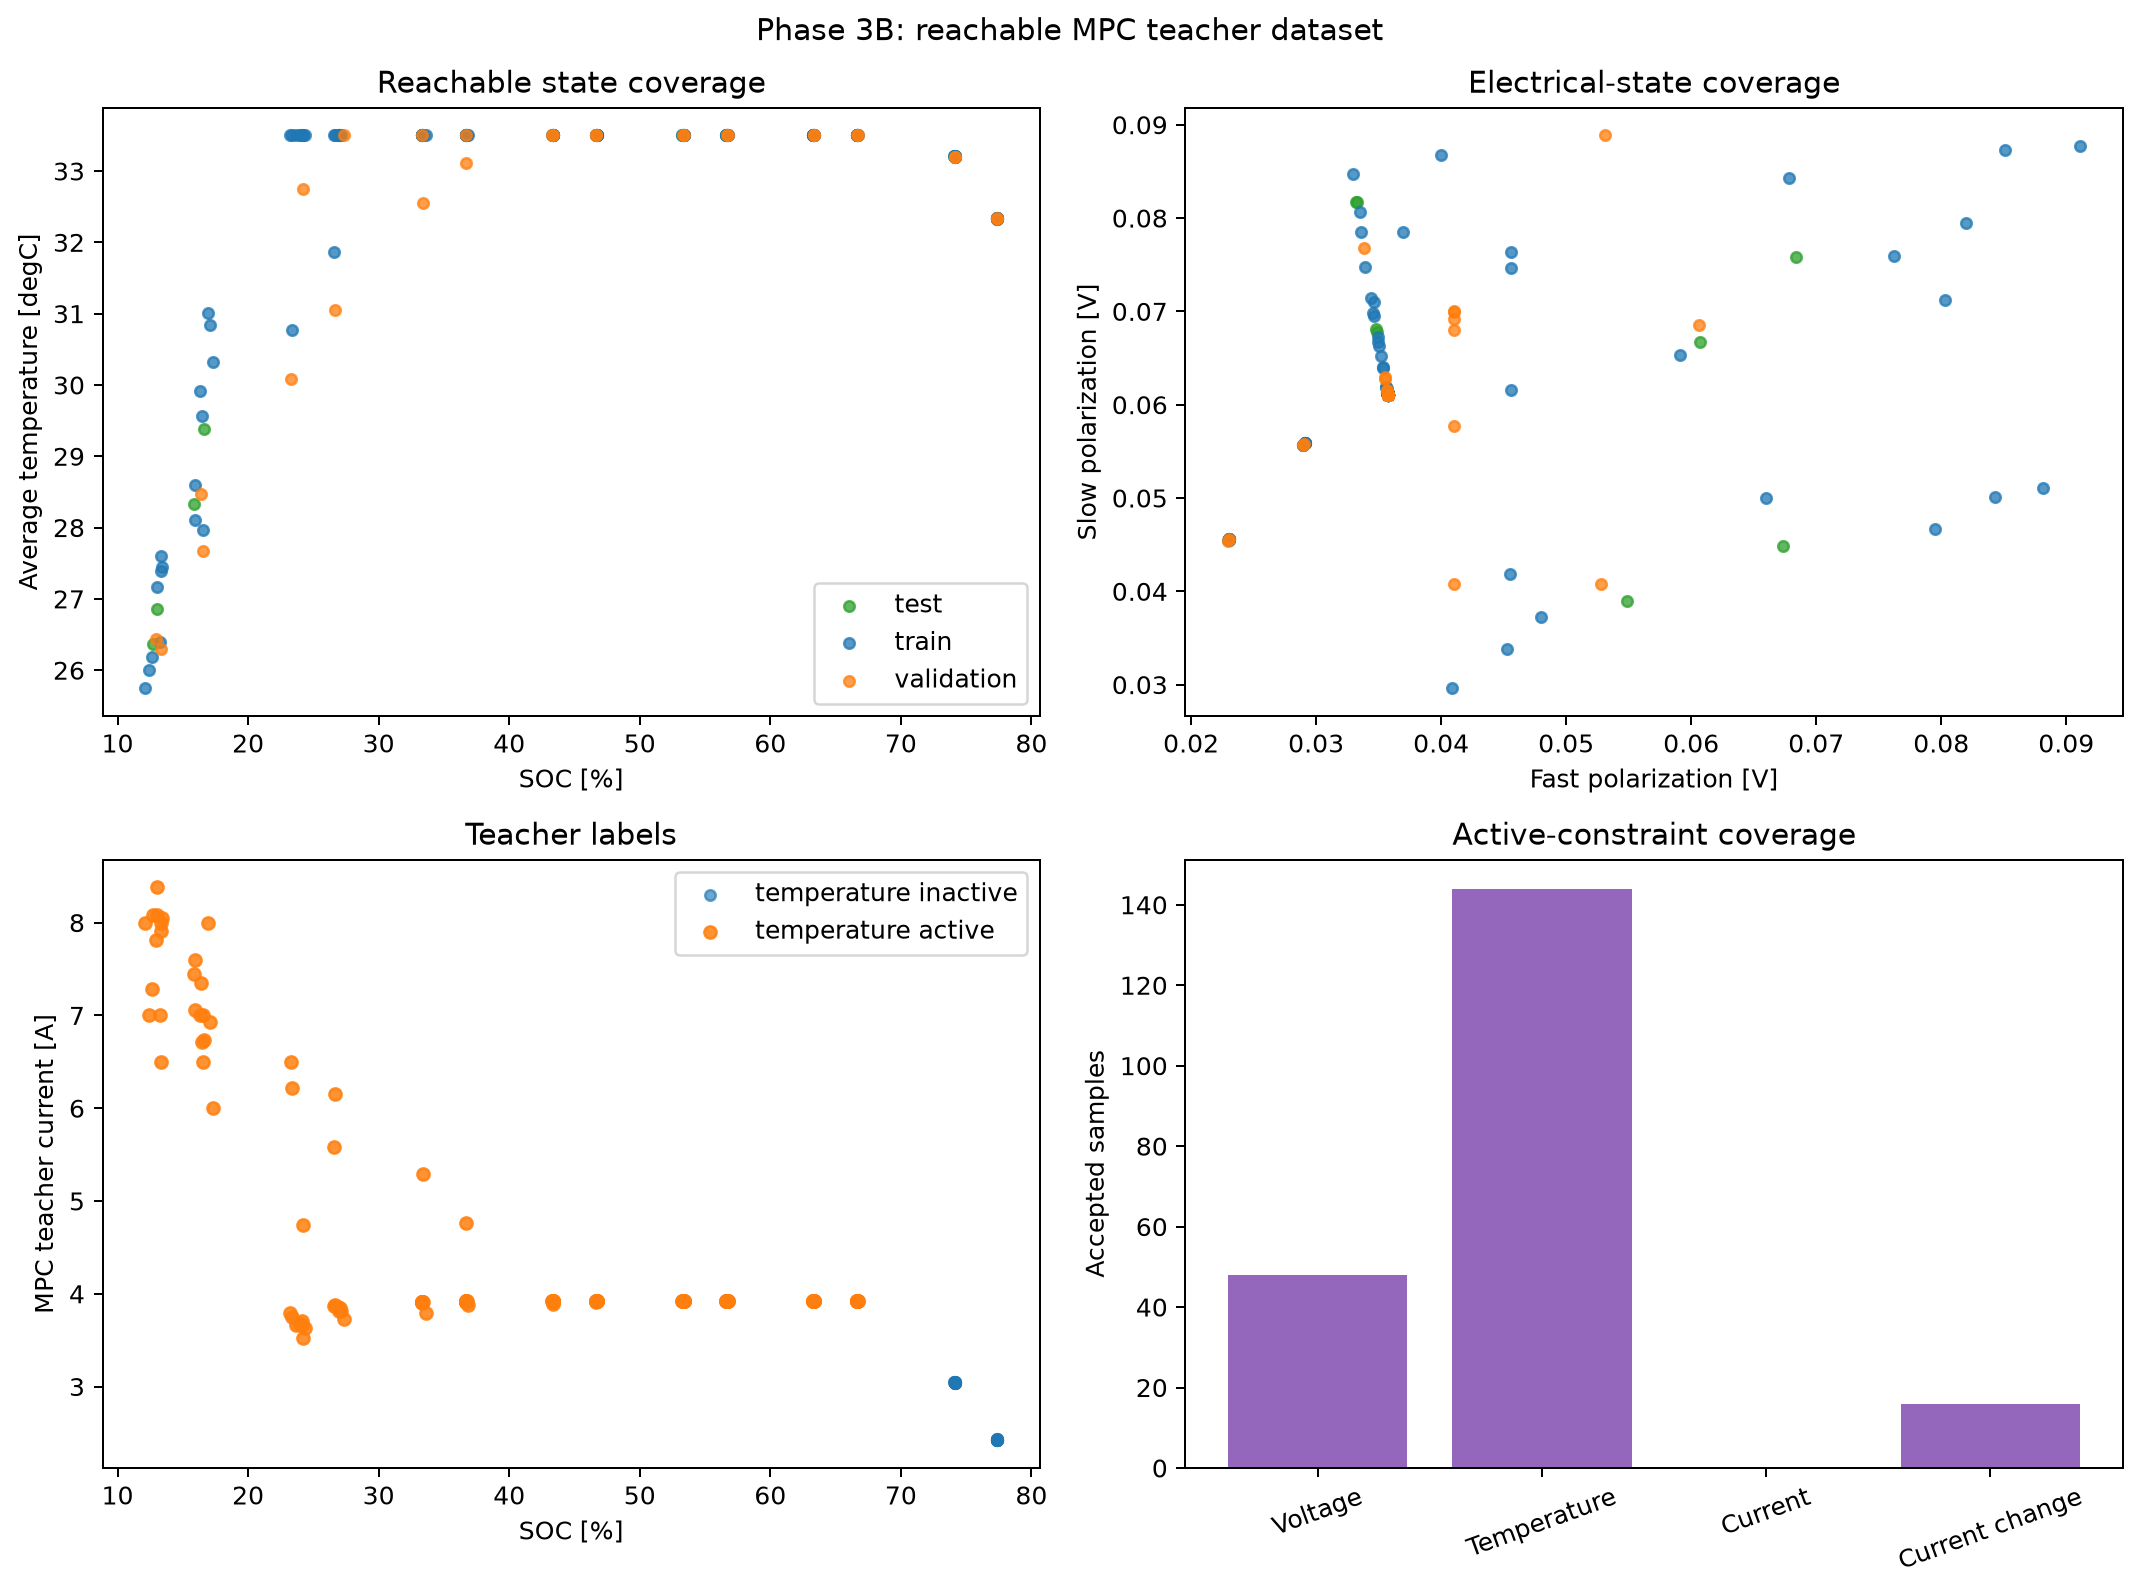

In [5]:
display(Image(filename=str(
    PROJECT_ROOT / "outputs" / "figures" / "phase3b_teacher_dataset_coverage.png"
)))

图中应重点检查：三个数据集是否覆盖完整 SOC 区间；教师电流是否随状态变化；训练、验证、测试是否来自不同轨迹；电压和温度约束附近是否有样本。当前温度活跃样本较多，而电流上限活跃样本为零，说明这组工况主要由热约束和电压约束决定，并非由 10 A 上限直接截断。

## 同约束公平基线

,controller,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_a,success
0,Filtered 1C baseline,53.3333,4.1425,33.5024,5.0000,True
1,Constrained MPC,53.5833,4.1425,33.5167,9.8326,True


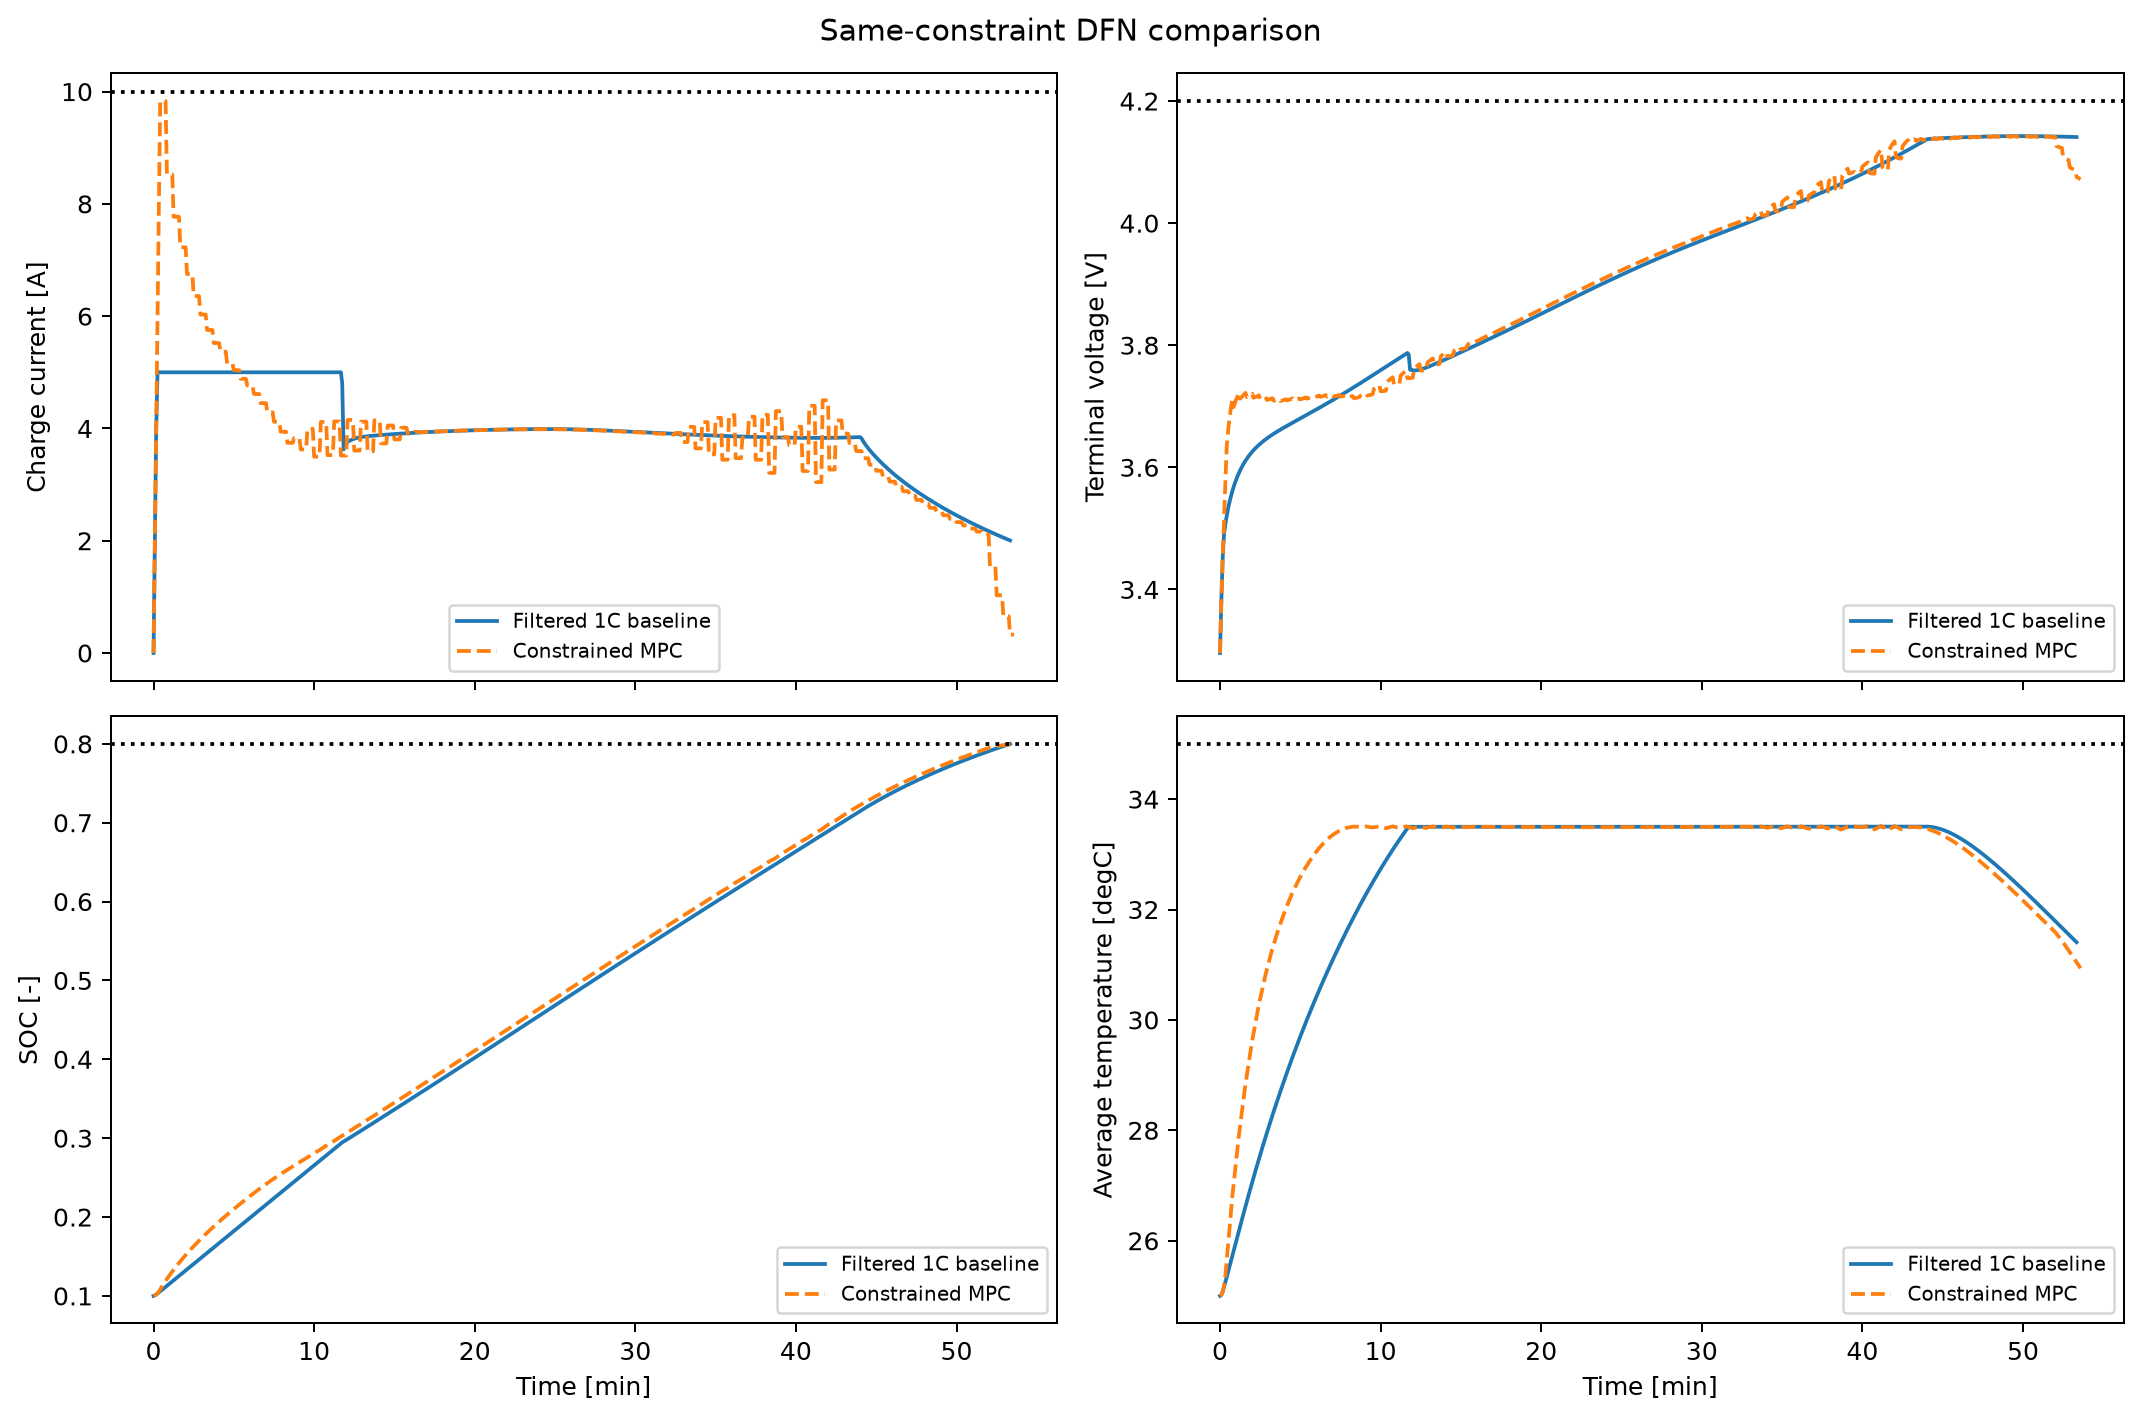

In [6]:
display(comparison.round(4))
display(Image(filename=str(
    PROJECT_ROOT / "outputs" / "figures" / "phase3b_same_constraint_comparison.png"
)))

两种控制器都使用 4.20 V、35 ℃、10 A 和每 5 s 最大 2 A 电流变化约束，并在 Chen2020 DFN 上检查。当前结果中，受安全过滤的 1C 基线比 MPC 快约 0.25 min。因此不能声称 MPC 已缩短充电时间；它目前的价值是生成满足约束、带有状态依赖变化的教师策略。后续应重新审视 MPC 目标函数、预测时域和温度收紧余量，并用闭环结果决定是否真正优于简单控制。

## 是否进入 DNN 训练？

In [7]:
decision = pd.Series({
    "教师数据质量通过": metrics["dataset_quality"]["success"],
    "公平基线满足约束": metrics["fair_baseline"]["success"],
    "MPC参考轨迹满足约束": metrics["mpc_reference"]["success"],
    "允许开始第一版DNN训练": metrics["ready_for_dnn_training"],
    "MPC比公平1C更快": (
        metrics["mpc_reference"]["charge_time_min"]
        < metrics["fair_baseline"]["charge_time_min"]
    ),
})
display(decision.to_frame("结果"))

,结果
教师数据质量通过,True
公平基线满足约束,True
MPC参考轨迹满足约束,True
允许开始第一版DNN训练,True
MPC比公平1C更快,False


## 结论与下一阶段边界

- 阶段 3B 通过，数据协议允许进入第一版 DNN 回归和闭环验证；
- DNN 训练必须只用 `train` 轨迹调参，用 `validation` 选择模型，最终只在 `test` 整轨迹报告一次；
- 不能只报告电流均方误差，必须重新接入安全过滤器并在 DFN 上报告终端 SOC、充电时间、约束违规率和安全覆盖次数；
- 168 个标签只适合验证流程，不足以证明跨温度、跨老化和实物部署泛化；
- 两支极化电压是模型内部状态，未来接入 BMS 前需要增加并验证状态观测器；
- 当前 MPC 未快于同约束 1C 基线，训练 DNN 是对教师策略的计算加速实验，不等于已经得到更优的充电策略。